# Chapter 24: How Much Capability Have We Extracted?

A procedure succeeds more often in a supplied table. That is the beginning of an evaluation, not its conclusion. Were the same tasks used? Did both procedures receive the same opportunities? Is the target population mostly easy tasks, mostly difficult tasks, or the mixture that happened to be logged? A single average cannot answer those questions.

This laboratory begins with one row per observed procedure, task, and run. Those identifiers do real work. They define the denominator for each procedure and identify matched comparisons where both procedures attempted the same task/run pair. The table also records optional cost and exposure, so an observed subset cannot quietly become the denominator for the whole evaluation.

The example is small enough to inspect by hand. The candidate repairs one of the baseline's failures while leaving the other outcomes unchanged. Count those pairs before reading the rate bars. Then change the target task mixture without changing any observations. Finally try a transfer table with no overlap between procedures. The correct result there is an unavailable matched effect, not an invented zero and not a claim that the raw rate difference estimates improvement.

**Outcome:** Report observed denominators, matched differences, uncertainty assumptions, and target mixtures.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- Sample means and paired observations

## The question and its mathematics

For procedure p, the observed success rate is s_p/n_p, where n_p counts all supplied rows for that procedure and s_p counts true success flags. This denominator is explicit. Exposure-conditional rates use only exposed rows and have a different denominator. They describe that observed subset; they do not automatically estimate success in the target task population.

For a matched task/run pair i, define d_i=Y_candidate,i-Y_baseline,i. Each difference is -1, 0, or 1. The matched mean is sum_i d_i/m over the m common pairs. When m is at least two, the reported standard error is the sample standard deviation of those differences divided by sqrt(m). This formula requires independent representative pairs for its usual sampling interpretation. Matching identifiers alone does not establish randomization or causal attribution.

The Wilson interval is reported for each procedure's binary rate. With z approximately 1.96, its center is (p_hat+z^2/(2n))/(1+z^2/n), and its half-width accounts for both p_hat(1-p_hat)/n and z^2/(4n^2). The interval is conditional on a binomial sampling model, not a universal confidence statement about correlated repeated tasks.

A target mixture uses weights w_t that sum to one and task-specific observed rates p_hat_p,t. Its estimate is sum_t w_t p_hat_p,t only when every positively represented task has observations for that procedure. Missing cells remain unavailable. None of these averages identifies the probability that an entire long trajectory succeeds.

## Apply this to an agent

Evaluate the complete agent procedure, including retries, tools, budget and stopping rule. Pair comparable task/run outcomes and report missing pairs. A success average does not identify a stepwise error law or a causal improvement.

## A calculation you can run

Validate the records before computing rates. Procedure, task, and run identifiers must be nonempty strings, successes and exposure flags must be exact booleans, costs must be finite and nonnegative, and duplicate procedure/task/run rows are rejected. These requirements prevent accidental double counting and ambiguous pairing.

The computation groups rows by procedure, calculates denominators and rates, and then forms a separate intersection of task/run keys for the declared baseline and candidate. The matched difference uses that intersection alone. If it is empty, the difference and standard error are unavailable. With one matched pair, the point difference exists but sample standard error does not.

Task weights are an optional second input boundary. They must form a normalized probability distribution over named tasks. The code computes task-specific rates from the supplied rows and reweights them without altering the records. The rate chart shows observed procedure averages; the paired-difference chart shows the individual common-pair differences. Consult the table and metrics together so an impressive average does not erase a thin denominator, missing task cell, or different observation cost.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 24
inputs = {'baseline': 'base',
 'candidate': 'new',
 'records': [{'procedure': 'base',
              'task': 'easy',
              'run': '0',
              'success': True,
              'cost': 1,
              'exposed': False},
             {'procedure': 'base',
              'task': 'hard',
              'run': '1',
              'success': False,
              'cost': 1,
              'exposed': True},
             {'procedure': 'base',
              'task': 'easy',
              'run': '2',
              'success': True,
              'cost': 1,
              'exposed': False},
             {'procedure': 'base',
              'task': 'hard',
              'run': '3',
              'success': False,
              'cost': 1,
              'exposed': True},
             {'procedure': 'new',
              'task': 'easy',
              'run': '0',
              'success': True,
              'cost': 2,
              'exposed': False},
             {'procedure': 'new',
              'task': 'hard',
              'run': '1',
              'success': True,
              'cost': 2,
              'exposed': True},
             {'procedure': 'new',
              'task': 'easy',
              'run': '2',
              'success': True,
              'cost': 2,
              'exposed': False},
             {'procedure': 'new',
              'task': 'hard',
              'run': '3',
              'success': False,
              'cost': 2,
              'exposed': True}],
 'task_weights': {'easy': 0.5, 'hard': 0.5}}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 24: matched-capability
What improvement is supported by these procedure-level task outcomes?
Evidence: constructed teaching example

Calculated quantities:
{
  "procedures": {
    "base": {
      "n": 4,
      "successes": 2,
      "rate": 0.5,
      "wilson_interval_iid": [
        0.1500389892,
        0.8499610108
      ],
      "mean_cost": 1.0,
      "cost_observed_n": 4,
      "exposed_n": 2,
      "exposed_rate": 0.0
    },
    "new": {
      "n": 4,
      "successes": 3,
      "rate": 0.75,
      "wilson_interval_iid": [
        0.3006418426,
        0.9544127392
      ],
      "mean_cost": 2.0,
      "cost_observed_n": 4,
      "exposed_n": 2,
      "exposed_rate": 0.5
    }
  },
  "matched_n": 4,
  "matched_difference": 0.25,
  "matched_standard_error_iid_pairs": 0.25,
  "task_mixture_rates": {
    "base": 0.5,
    "new": 0.75
  },
  "trajectory_success_estimate": null
}

Interpretation:
Rates use observed runs. Matched differences use only common task/run identifiers

The baseline succeeds on two of four runs, giving 0.5. The candidate succeeds on three of four, giving 0.75. All four task/run identifiers match, so the paired differences are 0,1,0,0 and their mean is 0.25. Their sample standard error is 0.25 under independent-pair sampling. The small table supports a descriptive matched improvement; it is not precise evidence of a deployment guarantee.

Easy-task rates are 1 for both procedures. Hard-task rates are 0 for the baseline and 0.5 for the candidate. Equal target weights reproduce 0.5 and 0.75. When the target mixture assigns 0.9 to hard tasks, the reweighted rates become 0.1 and 0.55. The observations did not change. The estimand did. Preserve that distinction when presenting the changed-case figure.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


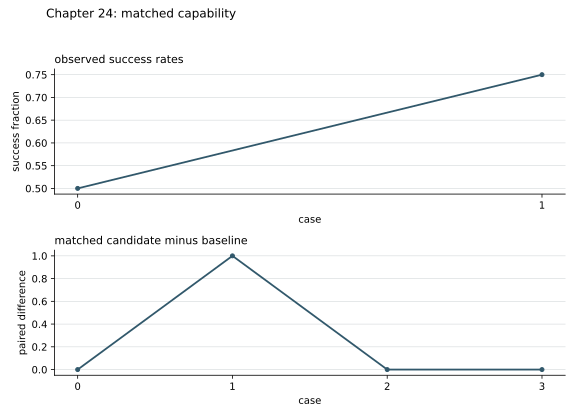

In [3]:
display(SVG(figure_svg(report)))

**Figure 24.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Repeated attempts can make a procedure's average look more certain than the task evidence warrants. Four runs on one task are not automatically equivalent to four independent tasks from a population. If failures share a document, environment state, or procedure configuration, the binomial and independent-pair uncertainty formulas can be too optimistic. Their names in the output keep those assumptions visible.

Another failure occurs when an observed subset is treated as the target population. Exposure may select difficult cases, favorable cases, or runs where a monitor was available. An exposure-conditional rate is useful only for its declared subset unless a sampling design justifies transport. The denominator should be reported beside the rate, including zero exposed observations as an unavailable conditional rate.

The transfer fixture contains different task/run keys for the two procedures. The raw rates still exist, but no matched difference can be calculated. Missing cells also prevent the proposed equal-task mixture from being estimated. Returning zero would falsely imply no difference; borrowing another procedure's outcome would fabricate evidence. The useful next step is to run both procedures on the missing matched tasks under the same evaluation contract.

Chapter 24: matched-capability
What improvement is supported by these procedure-level task outcomes?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "procedures": {
    "base": {
      "n": 4,
      "successes": 2,
      "rate": 0.5,
      "wilson_interval_iid": [
        0.1500389892,
        0.8499610108
      ],
      "mean_cost": 1.0,
      "cost_observed_n": 4,
      "exposed_n": 2,
      "exposed_rate": 0.0
    },
    "new": {
      "n": 4,
      "successes": 3,
      "rate": 0.75,
      "wilson_interval_iid": [
        0.3006418426,
        0.9544127392
      ],
      "mean_cost": 2.0,
      "cost_observed_n": 4,
      "exposed_n": 2,
      "exposed_rate": 0.5
    }
  },
  "matched_n": 4,
  "matched_difference": 0.25,
  "matched_standard_error_iid_pairs": 0.25,
  "task_mixture_rates": {
    "base": 0.1,
    "new": 0.55
  },
  "trajectory_success_estimate": null
}

Interpretation:
Rates use observed runs. Matched differences use only common task/run i

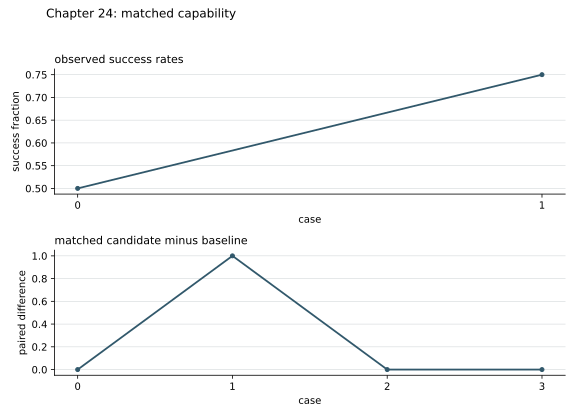

In [4]:
changed_inputs = {'baseline': 'base',
 'candidate': 'new',
 'records': [{'procedure': 'base',
              'task': 'easy',
              'run': '0',
              'success': True,
              'cost': 1,
              'exposed': False},
             {'procedure': 'base',
              'task': 'hard',
              'run': '1',
              'success': False,
              'cost': 1,
              'exposed': True},
             {'procedure': 'base',
              'task': 'easy',
              'run': '2',
              'success': True,
              'cost': 1,
              'exposed': False},
             {'procedure': 'base',
              'task': 'hard',
              'run': '3',
              'success': False,
              'cost': 1,
              'exposed': True},
             {'procedure': 'new',
              'task': 'easy',
              'run': '0',
              'success': True,
              'cost': 2,
              'exposed': False},
             {'procedure': 'new',
              'task': 'hard',
              'run': '1',
              'success': True,
              'cost': 2,
              'exposed': True},
             {'procedure': 'new',
              'task': 'easy',
              'run': '2',
              'success': True,
              'cost': 2,
              'exposed': False},
             {'procedure': 'new',
              'task': 'hard',
              'run': '3',
              'success': False,
              'cost': 2,
              'exposed': True}],
 'task_weights': {'easy': 0.1, 'hard': 0.9}}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 24.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

Apply this method to compatible local records by keeping the sampling unit explicit. If a run identifier denotes a random seed, environment instance, or attempt number, document that meaning before comparing procedures. Choose the success predicate before examining outcomes, and preserve costs even when they complicate an appealing success-rate story.

The transfer table demonstrates the missing-data boundary. Its old procedure has one success on alpha, while the proposal has one failure on beta. That is insufficient for a matched comparison or a two-task target estimate. Export a measurement request that names the missing alpha/proposal and beta/old cells. When the data are supplied, recompute the matched and mixture quantities. Avoid converting a procedure average into a per-step reliability law; trajectory completion needs run-level evidence or a declared conditional process.

In [5]:
transfer_inputs = {'baseline': 'old',
 'candidate': 'proposal',
 'records': [{'procedure': 'old',
              'task': 'alpha',
              'run': 'one',
              'success': True,
              'cost': 1},
             {'procedure': 'proposal',
              'task': 'beta',
              'run': 'two',
              'success': False,
              'cost': 3}],
 'task_weights': {'alpha': 0.5, 'beta': 0.5}}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 24: matched-capability
What improvement is supported by these procedure-level task outcomes?
Evidence: constructed transfer example

Calculated quantities:
{
  "procedures": {
    "old": {
      "n": 1,
      "successes": 1,
      "rate": 1.0,
      "wilson_interval_iid": [
        0.2065493144,
        1
      ],
      "mean_cost": 1.0,
      "cost_observed_n": 1,
      "exposed_n": 0,
      "exposed_rate": null
    },
    "proposal": {
      "n": 1,
      "successes": 0,
      "rate": 0.0,
      "wilson_interval_iid": [
        0,
        0.7934506856
      ],
      "mean_cost": 3.0,
      "cost_observed_n": 1,
      "exposed_n": 0,
      "exposed_rate": null
    }
  },
  "matched_n": 0,
  "matched_difference": null,
  "matched_standard_error_iid_pairs": null,
  "task_mixture_rates": {
    "old": null,
    "proposal": null
  },
  "trajectory_success_estimate": null
}

Interpretation:
Rates use observed runs. Matched differences use only common task/run identifiers; missing pa

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **baseline:** Observed baseline procedure identifier.
- **candidate:** Observed distinct candidate procedure identifier.
- **records:** List of records with procedure,task,run:string and success:exact boolean; optional cost:nonnegative number, exposed:exact boolean. Procedure/task/run must be unique.
- **task_weights:** Optional object of task identifiers to normalized probabilities defining a target mixture.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch24.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 24: matched-capability
What improvement is supported by these procedure-level task outcomes?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "procedures": {
    "old": {
      "n": 1,
      "successes": 1,
      "rate": 1.0,
      "wilson_interval_iid": [
        0.2065493144,
        1
      ],
      "mean_cost": 1.0,
      "cost_observed_n": 1,
      "exposed_n": 0,
      "exposed_rate": null
    },
    "proposal": {
      "n": 1,
      "successes": 0,
      "rate": 0.0,
      "wilson_interval_iid": [
        0,
        0.7934506856
      ],
      "mean_cost": 3.0,
      "cost_observed_n": 1,
      "exposed_n": 0,
      "exposed_rate": null
    }
  },
  "matched_n": 0,
  "matched_difference": null,
  "matched_standard_error_iid_pairs": null,
  "task_mixture_rates": {
    "old": null,
    "proposal": null
  },
  "trajectory_success_estimate": null
}

Interpretation:
Rates use observed runs. Matched differences use only common 

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c24-d01"></a>

### Demonstration 1: Observations, denominators and estimands

What do these observations support, and which quantities change when the sample size, the pairing or the target mixture changes while the records stay the same?

![Equation 24.1](../assets/math/886a2c6b1896a4538022.svg)

![Equation 24.2](../assets/math/045e257aff580c8bb95a.svg)

**Symbols and units:** A score is the average of the scored outcomes u_j over N_eval evaluation instances (Equation 24.1), for one named system, task draw, scoring rule and contract V. Delta_match is the benchmark pass proportion minus the matched-bank pass proportion for the same fixed model. The two-bank case has independent tasks, so the standard error of the gap is sqrt(p1(1 - p1)/n + p2(1 - p2)/n) and the 95% interval is the gap plus or minus 1.96 standard errors. The record cases come from the laboratory's paired design: a procedure's rate is its successes over its own runs, a matched difference uses only task/run pairs both procedures attempted, and a target mixture weights task-specific rates and needs every positively weighted task observed. The aged-benchmark case mixes success on unfamiliar tasks (0.4) with success on exposed tasks (1.0) at an exposed share of 20 percent.

Every score is an average over a stated denominator, so the first thing to read is what was counted. A gap between two independent banks has noise that adds, and that noise falls with the number of tasks. When the records are paired, only the pairs both procedures attempted enter the difference, and when records do not overlap the matched difference does not exist. A target mixture changes the estimand without touching a single observation, and a mixture with exposed tasks can raise the aggregate without any gain on unfamiliar tasks.

**Use in this chapter:** Before reporting that a procedure improved, report each denominator, the number of matched pairs, the interval and the target mixture, so a reader can tell a real discrepancy from a thin sample, a missing cell or a changed population.

**Assumptions:** The two-bank interval needs independent samples with adequately populated pass and fail counts and does not cover choosing the largest gap after inspecting many models. The paired standard error and the Wilson intervals need independent representative pairs or runs, which repeated runs of the same task may violate; identifiers declare pairing, not randomization. The aged-benchmark mixture is the chapter's declared construction, not a measured contamination effect.

**Predict before running:** In the two-bank case on 'The difference between two scores', the same 0.07 gap is shown at 100, 400 and 1600 tasks per bank. At 100 tasks does the interval include zero?

**Controls you can change:**

- **Observations:** `case` accepts 'book', 'lab', 'transfer', 'aged'.
- **What to read off:** `reading` accepts 'scores', 'gap', 'weights'.

**Source section:** The matched question is not the same question twice.

**Evidence:** constructed teaching example.

Constructed example: the book's teaching counts (320 and 292 passes out of 400, not GSM1k measurements), the laboratory's default, changed and transfer record cases evaluated with the laboratory's own function, and the chapter's constructed aged-benchmark mixture (0.4 unfamiliar, 1.0 exposed, 20 percent exposed).

Prediction choices:

1. Yes: at 100 tasks the interval is about 0.07 plus or minus 0.117, so it includes zero
2. No: a gap of 0.07 always excludes zero
3. It cannot be said without the cause of the gap

**Boundary of the conclusion:** A matched held-out set can strengthen one comparison while leaving unmeasured task differences, selection effects and transfer limits open. The bounded conclusion is that an evaluation supports claims about the declared system, protocol, sample and task distribution that produced its score.

**Common wrong turn:** The chapter says the interval excludes zero under its sampling model but does not identify contamination, memorization, changed reasoning or an unmatched task feature as the cause. Matching observed features is not randomized assignment of training exposure.

Observations, denominators and estimands
Controls: {"case": "book", "reading": "scores"}
Evidence: constructed teaching example

Calculated quantities:
Benchmark score: 0.80
Matched score: 0.73
Tasks in each bank: 400
Half-width, benchmark: 0.0392
Half-width, matched: 0.0435

Worked steps:
1. Benchmark: 320 passes of 400 tasks, so 320 / 400 = 0.80.
2. Matched: 292 passes of 400 tasks, so 292 / 400 = 0.73.
3. Benchmark half-width = 1.96 x sqrt(0.80 x 0.20 / 400) = 0.0392.
4. Matched half-width = 1.96 x sqrt(0.73 x 0.27 / 400) = 0.0435.

Benchmark = (1 / 400) x 320 = 0.80; matched = (1 / 400) x 292 = 0.73, the average of the scored outcomes in each bank (Equation 24.1). Half-widths: 1.96 x sqrt(0.80 x 0.20 / 400) = 0.0392 and 1.96 x sqrt(0.73 x 0.27 / 400) = 0.0435. Each score is only meaningful with its denominator and its contract.

Assumptions: The two-bank interval needs independent samples with adequately populated pass and fail counts and does not cover choosing the largest gap aft

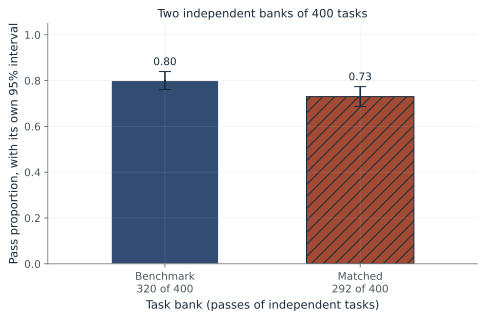

In [8]:
demo_id = 'C24-D01'
demo_controls = {'case': 'book', 'reading': 'scores'}
demo_result = run_demo(24, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Observations** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Observations, denominators and estimands
Controls: {"case": "lab", "reading": "scores"}
Evidence: constructed teaching example

Calculated quantities:
Base score (all runs): 0.50
New score (all runs): 0.75
Base 95% Wilson interval: [0.150, 0.850]
New 95% Wilson interval: [0.301, 0.954]
Exposed rate, base and new: 0.00 of 2 and 0.50 of 2

Worked steps:
1. Base succeeds on 2 of 4 runs: 2 / 4 = 0.50.
2. New succeeds on 3 of 4 runs: 3 / 4 = 0.75.
3. Exposed runs are the two hard runs of each procedure: base 0 / 2 = 0.00, new 1 / 2 = 0.50.
4. Intervals are Wilson intervals under independent sampling, reported by the laboratory.

Base = 2 / 4 = 0.50; new = 3 / 4 = 0.75 (Equation 24.1 on each procedure's runs). Exposed runs are the two hard runs of each procedure: base 0 / 2 = 0.00, new 1 / 2 = 0.50. The exposed rate has a different denominator and describes only that subset. The intervals assume independent, representative runs, which four runs on two tasks cannot establish.

Assumptions: Th

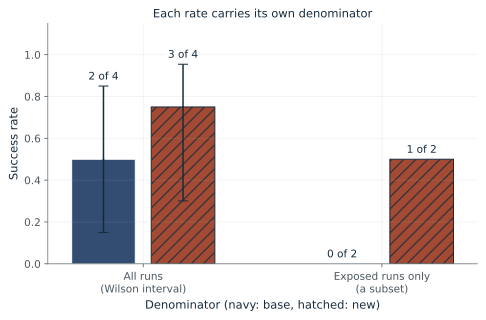

In [9]:
changed_controls = {'case': 'lab', 'reading': 'scores'}
changed_demo = run_demo(24, 'C24-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(24, 'C24-D01'):
    state = run_demo(24, 'C24-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "book",
      "reading": "scores"
    },
    "metrics": [
      [
        "Benchmark score",
        "0.80"
      ],
      [
        "Matched score",
        "0.73"
      ],
      [
        "Tasks in each bank",
        "400"
      ],
      [
        "Half-width, benchmark",
        "0.0392"
      ],
      [
        "Half-width, matched",
        "0.0435"
      ]
    ]
  },
  {
    "controls": {
      "case": "book",
      "reading": "gap"
    },
    "metrics": [
      [
        "Gap (Equation 24.2)",
        "0.070"
      ],
      [
        "Standard error at 100 tasks",
        "0.05976"
      ],
      [
        "Standard error at 400 tasks",
        "0.02988"
      ],
      [
        "Standard error at 1600 tasks",
        "0.01494"
      ],
      [
        "95% interval at 400 tasks",
        "[0.01144, 0.12856]"
      ],
      [
        "Interval excludes zero at 100, 400, 1600",
        "no, yes, yes"
      ]
    ]
  },
  {
    "controls": {


**Check your understanding:** Work this one by hand (800 tasks per bank is not shown). Benchmark 0.80 and matched 0.73 on 800 tasks each: what is the standard error of the gap, and does the interval exclude zero? And what is the aged benchmark's aggregate if 50 percent of its tasks were exposed?

[Answer and worked reasoning](../solutions/ch24.md#demonstration-1). [Matching browser demonstration](../readers/24-matched-capability/reader.html#C24-D01).

<a id="demo-c24-d02"></a>

### Demonstration 2: An onset belongs to its threshold

If a score rises gradually with scale, how much does the reported onset of a capability depend on the chosen threshold and on which sizes were tested?

![Equation 24.3](../assets/math/1344d05a793fef025f76.svg)

**Symbols and units:** m numbers the members of a model family in their declared scale order. g(m) is a continuous score under one fixed protocol. zeta is the threshold. Onset is the smallest m whose score reaches zeta; inf means the smallest such value in the tested set. If the set is empty there is no onset.

The score curve is smooth, but a pass indicator turns on at the first member that reaches the threshold. Raising the threshold moves that crossing to the right. Testing fewer members can move it further, and can remove it from the tested set altogether. The onset is a property of the curve, the threshold and the sampling of sizes together.

**Use in this chapter:** When someone reports that an ability appears at a certain size, ask for the continuous curve, the threshold, and the onset at two or three nearby thresholds. If the onset moves a lot, say the onset is threshold-sensitive.

**Assumptions:** One constructed curve of eight ordered members under one stable protocol, with no sampling noise on g. A crossing is an operational record, not a certified phase transition. Real scores carry uncertainty that could move a crossing by itself.

**Predict before running:** At threshold 0.70 with only members 1, 3, 5 and 7 tested, is there an onset?

**Controls you can change:**

- **Threshold zeta:** `threshold` accepts 0.3, 0.5, 0.6, 0.7.
- **Family members tested:** `tested` accepts 'all', 'odd', 'even'.

**Source section:** Scale profiles and extraction profiles are different maps.

**Evidence:** constructed teaching example.

Constructed example: eight family scores defined for this reader (0.04, 0.09, 0.17, 0.30, 0.46, 0.58, 0.66, 0.71), not a measured scale profile.

Prediction choices:

1. Yes, at m = 7
2. Yes, at m = 8
3. No: no tested member reaches 0.70, so the onset is undefined

**Boundary of the conclusion:** The chapter leaves a model's maximum capability, a universal measure of reasoning and a complete cause of any benchmark gap open. A tested set leaves untested prompts, tools, budgets, selectors and future model states open.

**Common wrong turn:** The chapter says Equation (24.3) cannot certify a phase transition: it records an operational crossing that depends on the threshold, the metric, the family order and the protocol, and practical importance does not make the threshold a law of nature.

An onset belongs to its threshold
Controls: {"threshold": 0.5, "tested": "all"}
Evidence: constructed teaching example

Calculated quantities:
Threshold: 0.50
Members tested: 1, 2, 3, 4, 5, 6, 7, 8
Onset: m = 6
Highest tested score: 0.71
Onset with all eight tested: m = 6

Worked steps:
1. Threshold zeta = 0.50; tested members: 1, 2, 3, 4, 5, 6, 7, 8.
2. Scores of the tested members: g(1) = 0.04, g(2) = 0.09, g(3) = 0.17, g(4) = 0.30, g(5) = 0.46, g(6) = 0.58, g(7) = 0.66, g(8) = 0.71.
3. The first tested member with g(m) >= zeta is m = 6.
4. With all eight members the onset would be m = 6.

Smallest tested m with g(m) >= 0.50 is m = 6, where g(6) = 0.58; margin = 0.58 - 0.50 = 0.08. The member before it in this tested set is m = 5 with g = 0.46, 0.04 short of the threshold. The score curve rises gradually; only the declared threshold turns it into a pass. A different threshold or a sparser tested set can move this onset.

Assumptions: One constructed curve of eight ordered members und

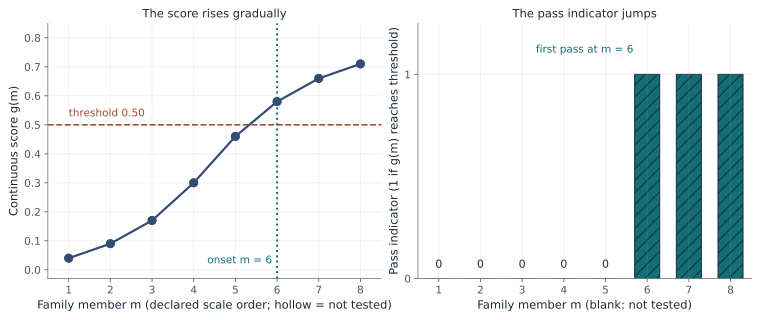

In [11]:
demo_id = 'C24-D02'
demo_controls = {'threshold': 0.5, 'tested': 'all'}
demo_result = run_demo(24, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Threshold zeta** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

An onset belongs to its threshold
Controls: {"threshold": 0.3, "tested": "all"}
Evidence: constructed teaching example

Calculated quantities:
Threshold: 0.30
Members tested: 1, 2, 3, 4, 5, 6, 7, 8
Onset: m = 4
Highest tested score: 0.71
Onset with all eight tested: m = 4

Worked steps:
1. Threshold zeta = 0.30; tested members: 1, 2, 3, 4, 5, 6, 7, 8.
2. Scores of the tested members: g(1) = 0.04, g(2) = 0.09, g(3) = 0.17, g(4) = 0.30, g(5) = 0.46, g(6) = 0.58, g(7) = 0.66, g(8) = 0.71.
3. The first tested member with g(m) >= zeta is m = 4.
4. With all eight members the onset would be m = 4.

Smallest tested m with g(m) >= 0.30 is m = 4, where g(4) = 0.30; margin = 0.30 - 0.30 = 0.00. The member before it in this tested set is m = 3 with g = 0.17, 0.13 short of the threshold. The score curve rises gradually; only the declared threshold turns it into a pass. A different threshold or a sparser tested set can move this onset.

Assumptions: One constructed curve of eight ordered members und

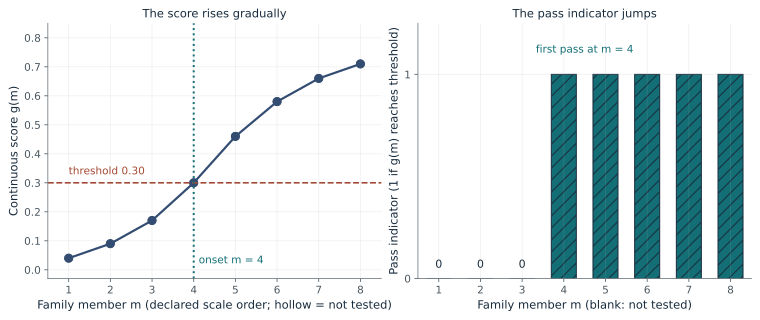

In [12]:
changed_controls = {'threshold': 0.3, 'tested': 'all'}
changed_demo = run_demo(24, 'C24-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(24, 'C24-D02'):
    state = run_demo(24, 'C24-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "threshold": 0.3,
      "tested": "all"
    },
    "metrics": [
      [
        "Threshold",
        "0.30"
      ],
      [
        "Members tested",
        "1, 2, 3, 4, 5, 6, 7, 8"
      ],
      [
        "Onset",
        "m = 4"
      ],
      [
        "Highest tested score",
        "0.71"
      ],
      [
        "Onset with all eight tested",
        "m = 4"
      ]
    ]
  },
  {
    "controls": {
      "threshold": 0.3,
      "tested": "odd"
    },
    "metrics": [
      [
        "Threshold",
        "0.30"
      ],
      [
        "Members tested",
        "1, 3, 5, 7"
      ],
      [
        "Onset",
        "m = 5"
      ],
      [
        "Highest tested score",
        "0.66"
      ],
      [
        "Onset with all eight tested",
        "m = 4"
      ]
    ]
  },
  {
    "controls": {
      "threshold": 0.3,
      "tested": "even"
    },
    "metrics": [
      [
        "Threshold",
        "0.30"
      ],
      [
        "Members teste

**Check your understanding:** With all eight members tested, what is the onset at threshold 0.60? And with only the even members tested?

[Answer and worked reasoning](../solutions/ch24.md#demonstration-2). [Matching browser demonstration](../readers/24-matched-capability/reader.html#C24-D02).

<a id="demo-c24-d03"></a>

### Demonstration 3: A lower frontier is evidence, not a ceiling

If several configurations are tested, what can we claim for the best one after paying for having looked at all of them?

![Equation 24.4](../assets/math/51e54aadcb3e927d56f9.svg)

**Symbols and units:** C is the finite set of tested configurations, xi one of them, and U its true success rate under the stated contract. Lower is a bound from a joint procedure that holds for every configuration at once with probability at least 1 minus alpha. LCF is the largest of those bounds. Here alpha is 0.05 and n is the number of tasks per configuration. In Equation (24.4), V is the declared evaluation contract (task distribution, evaluation unit, scoring rule, component partition, information and action interfaces, budget, horizon and baseline), S_xi is the set of components enabled in configuration xi, and Lower^sim is instantiated here as the observed rate minus the margin t.

Each configuration's lower bound is its observed rate minus a margin. To make all bounds hold together, the allowed failure probability is split across the tested configurations, which widens the margin. The frontier is the largest of those lower bounds. Configurations that were not tested do not appear in the maximum.

**Use in this chapter:** If a program tries several prompts, tools or budgets, report how many were tried and use a margin that pays for the search, instead of presenting the highest score as if it were the only planned comparison.

**Assumptions:** The margin used here is one way to build the joint bound: a one-sided Hoeffding deviation for independent tasks scored between 0 and 1, with the failure budget split equally by a union bound. Other designs give other margins. If tasks are dependent, the independence-based margin is no longer justified (and may be too small under positive dependence).

**Predict before running:** Keep 400 tasks but test only the first two configurations. Does the margin t shrink or grow compared with testing four?

**Controls you can change:**

- **Tasks per configuration:** `tasks` accepts 100, 400, 1600.
- **Configurations tested:** `tested` accepts 2, 3, 4.

**Source section:** A frontier is lower evidence, not a final ceiling.

**Evidence:** constructed teaching example.

Constructed example: four configuration success rates (0.60, 0.68, 0.72, 0.74) defined for this reader, not results for any real system.

Prediction choices:

1. It shrinks, because fewer configurations share the failure budget
2. It grows
3. It stays the same

**Boundary of the conclusion:** A tested lower frontier leaves untested prompts, tools, budgets, selectors and future model states open. An evaluation supports claims about the declared system, protocol, sample and task distribution that produced its score.

**Common wrong turn:** The chapter calls the frontier a lower frontier: the best tested result is evidence that at least that much was extracted under one tested configuration, and it leaves a finite tested set open to better untested configurations.

A lower frontier is evidence, not a ceiling
Controls: {"tasks": 400, "tested": 4}
Evidence: constructed teaching example

Calculated quantities:
Configurations tested: 4
Simultaneous margin t: 0.074
Margin if one configuration were tested alone: 0.061
Frontier value (LCF): 0.666
Configuration that sets it: Tools and selector

Worked steps:
1. Each configuration gets alpha / 4 = 0.0125 of the failure budget.
2. Margin t = sqrt(ln(4/0.05) / (2 x 400)) = 0.074.
3. Lower bounds: Direct prompt 0.60 - 0.074 = 0.526, Retrieval 0.68 - 0.074 = 0.606, Retrieval and tools 0.72 - 0.074 = 0.646, Tools and selector 0.74 - 0.074 = 0.666.
4. LCF is the largest lower bound, 0.666, set by Tools and selector.

Margin t = sqrt(ln(4/0.05) / (2 x 400)) = sqrt(4.382 / 800) = 0.074. Lower bound for Tools and selector = 0.74 - 0.074 = 0.666, the largest of the 4 jointly supported bounds, so LCF = 0.666. Testing one configuration alone would use sqrt(ln(1/0.05) / (2 x 400)) = 0.061; the extra 0.013 is the price

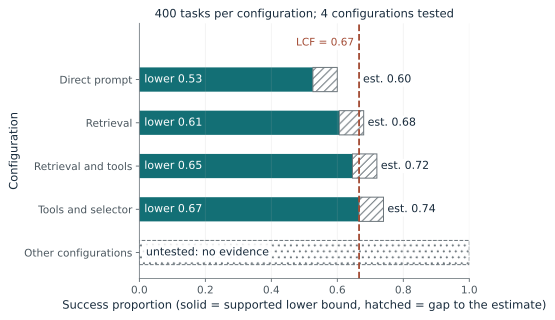

In [14]:
demo_id = 'C24-D03'
demo_controls = {'tasks': 400, 'tested': 4}
demo_result = run_demo(24, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Tasks per configuration** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A lower frontier is evidence, not a ceiling
Controls: {"tasks": 100, "tested": 4}
Evidence: constructed teaching example

Calculated quantities:
Configurations tested: 4
Simultaneous margin t: 0.148
Margin if one configuration were tested alone: 0.122
Frontier value (LCF): 0.592
Configuration that sets it: Tools and selector

Worked steps:
1. Each configuration gets alpha / 4 = 0.0125 of the failure budget.
2. Margin t = sqrt(ln(4/0.05) / (2 x 100)) = 0.148.
3. Lower bounds: Direct prompt 0.60 - 0.148 = 0.452, Retrieval 0.68 - 0.148 = 0.532, Retrieval and tools 0.72 - 0.148 = 0.572, Tools and selector 0.74 - 0.148 = 0.592.
4. LCF is the largest lower bound, 0.592, set by Tools and selector.

Margin t = sqrt(ln(4/0.05) / (2 x 100)) = sqrt(4.382 / 200) = 0.148. Lower bound for Tools and selector = 0.74 - 0.148 = 0.592, the largest of the 4 jointly supported bounds, so LCF = 0.592. Testing one configuration alone would use sqrt(ln(1/0.05) / (2 x 100)) = 0.122; the extra 0.026 is the price

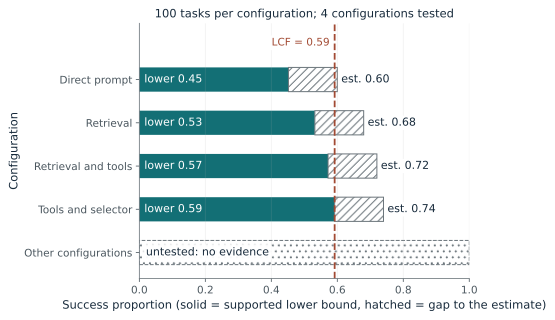

In [15]:
changed_controls = {'tasks': 100, 'tested': 4}
changed_demo = run_demo(24, 'C24-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(24, 'C24-D03'):
    state = run_demo(24, 'C24-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "tasks": 100,
      "tested": 2
    },
    "metrics": [
      [
        "Configurations tested",
        "2"
      ],
      [
        "Simultaneous margin t",
        "0.136"
      ],
      [
        "Margin if one configuration were tested alone",
        "0.122"
      ],
      [
        "Frontier value (LCF)",
        "0.544"
      ],
      [
        "Configuration that sets it",
        "Retrieval"
      ]
    ]
  },
  {
    "controls": {
      "tasks": 100,
      "tested": 3
    },
    "metrics": [
      [
        "Configurations tested",
        "3"
      ],
      [
        "Simultaneous margin t",
        "0.143"
      ],
      [
        "Margin if one configuration were tested alone",
        "0.122"
      ],
      [
        "Frontier value (LCF)",
        "0.577"
      ],
      [
        "Configuration that sets it",
        "Retrieval and tools"
      ]
    ]
  },
  {
    "controls": {
      "tasks": 100,
      "tested": 4
    },
    "metrics": [


**Check your understanding:** With 1600 tasks and four configurations tested at alpha 0.05, what is the margin t, and what is the frontier for a best estimate of 0.74?

[Answer and worked reasoning](../solutions/ch24.md#demonstration-3). [Matching browser demonstration](../readers/24-matched-capability/reader.html#C24-D03).

<a id="demo-c24-d04"></a>

### Demonstration 4: Same average, different reliability

If two banks of tasks both average 0.50 per run, do they give the same chance that repeated runs succeed, and what do the observed runs of one task give?

![Mathematical relation](../assets/demo-equations/016a9127f87ede9a40cc.svg)

![Mathematical relation](../assets/demo-equations/185f6b11d7d0cf06b490.svg)

**Symbols and units:** The bank has two equally weighted tasks with single-run success probabilities p1 and p2. Runs are independent given the task. k is the number of runs. The chapter writes the single-task cases for one run probability 0.9 and three runs: success at least once, 1 - (1 - p)^k, and success on all runs, p^k. This demonstration applies each to each task, averages, and compares with applying it to the mean rate. The recorded bank is one task with 4 observed runs and 3 successes: a k-run subset contains only successes with fraction C(3,k) / C(4,k) and at least one success with fraction 1 - C(1,k) / C(4,k), where C(n,k) counts the ways to choose k of n runs.

The task is drawn once and then repeated, so the runs share the task's difficulty. Averaging p^k over tasks weights the easy task heavily, giving more than the mean squared. Averaging 1 - (1 - p)^k over tasks gives less than the mean-rate formula. The gap grows with the spread between tasks and vanishes when the tasks are the same. For a recorded bank the subset fractions count the observed runs directly, and they differ from plugging the observed rate into the formulas.

**Use in this chapter:** When a report gives one average success rate and then claims reliability over repeated runs, ask for the task-level repeat results. The pooled average cannot answer a question about repetition.

**Assumptions:** Two constructed tasks, equal weights, runs independent given the task and a frozen procedure. It fails when runs share a cached error, quota or evaluator fault, and it says nothing about a selector that must choose among the runs before the answer is known. The subset fractions are unbiased only under independent, identically distributed trials for that fixed task; otherwise they are descriptive fractions of the bank, and if fewer than k runs exist the subset metric is unavailable.

**Predict before running:** With tasks at 0.20 and 0.80 and two runs, is the true chance that both runs succeed above or below 0.25, the square of the 0.50 mean?

**Controls you can change:**

- **Bank of tasks:** `bank` accepts '0.50', '0.20', '0.10', 'recorded'.
- **Runs per task (subset size for the recorded bank):** `runs` accepts 2, 3.

**Source section:** The same average can describe different reliability.

**Evidence:** constructed teaching example.

Constructed example: the chapter's two-task construction (0.2 and 0.8, mean 0.5) with other spreads and run counts added for this reader, and the recorded bank of three successes and one failure from Mathematical Workbench E.5, part 3.

Prediction choices:

1. Above: 0.34
2. Below: 0.16
3. Equal to 0.25

**Boundary of the conclusion:** The chapter leaves a model's maximum capability, a universal measure of reasoning and a complete cause of any benchmark gap open. The bounded conclusion is that an evaluation supports claims about the declared system, protocol, sample and task distribution that produced its score.

**Common wrong turn:** The chapter says raising an average success rate to a power assumes away the variation that repetition is meant to expose: squaring the mean gives 0.25 where the task-first average gives 0.34, and applying coverage to the mean gives 0.75 where the task-first average gives 0.66.

Same average, different reliability
Controls: {"bank": "0.20", "runs": 2}
Evidence: constructed teaching example

Calculated quantities:
Mean single-run success: 0.50
All runs, average of tasks: 0.340
All runs, mean-rate formula: 0.250
At least one, average of tasks: 0.660
At least one, mean-rate formula: 0.750

Worked steps:
1. Task rates 0.20 and 0.80; mean single-run rate 0.50.
2. All 2 runs per task: 0.20^2 = 0.0400 and 0.80^2 = 0.6400; average 0.340.
3. At least one in 2 runs: 0.3600 and 0.9600; average 0.660.
4. Mean-rate formulas: 0.50^2 = 0.250 and 1 - (1 - 0.50)^2 = 0.750.

All 2 runs: (0.20^2 + 0.80^2) / 2 = (0.0400 + 0.6400) / 2 = 0.340, while 0.50^2 = 0.250. At least one: ((1 - 0.80^2) + (1 - 0.20^2)) / 2 = (0.3600 + 0.9600) / 2 = 0.660, while 1 - (1 - 0.50)^2 = 0.750. Squaring the mean rate misses by 0.090 for all-runs success (it understates) and the coverage-style formula misses by 0.090 for at-least-one success (it overstates). The task is drawn once and then repeated, 

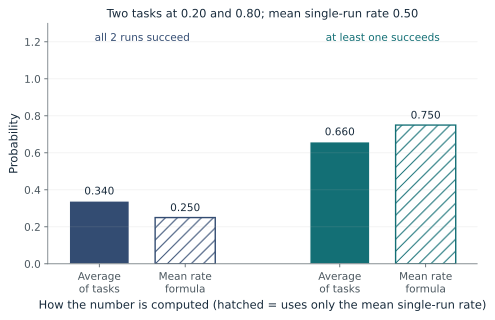

In [17]:
demo_id = 'C24-D04'
demo_controls = {'bank': '0.20', 'runs': 2}
demo_result = run_demo(24, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Bank of tasks** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Same average, different reliability
Controls: {"bank": "0.50", "runs": 2}
Evidence: constructed teaching example

Calculated quantities:
Mean single-run success: 0.50
All runs, average of tasks: 0.250
All runs, mean-rate formula: 0.250
At least one, average of tasks: 0.750
At least one, mean-rate formula: 0.750

Worked steps:
1. Task rates 0.50 and 0.50; mean single-run rate 0.50.
2. All 2 runs per task: 0.50^2 = 0.2500 and 0.50^2 = 0.2500; average 0.250.
3. At least one in 2 runs: 0.7500 and 0.7500; average 0.750.
4. Mean-rate formulas: 0.50^2 = 0.250 and 1 - (1 - 0.50)^2 = 0.750.

All 2 runs: (0.50^2 + 0.50^2) / 2 = (0.2500 + 0.2500) / 2 = 0.250, while 0.50^2 = 0.250. At least one: ((1 - 0.50^2) + (1 - 0.50^2)) / 2 = (0.7500 + 0.7500) / 2 = 0.750, while 1 - (1 - 0.50)^2 = 0.750. Both tasks have the same success rate, so there is no spread between tasks and the mean-rate formulas agree with the task-by-task averages. The two methods only differ when tasks differ.

Assumptions: Two con

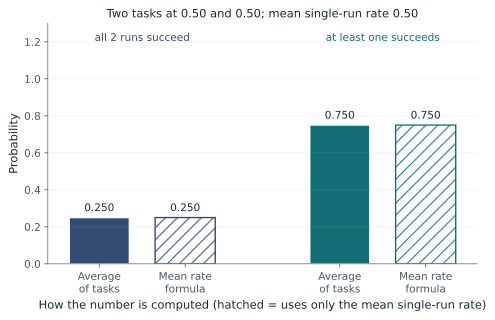

In [18]:
changed_controls = {'bank': '0.50', 'runs': 2}
changed_demo = run_demo(24, 'C24-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(24, 'C24-D04'):
    state = run_demo(24, 'C24-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "bank": "0.50",
      "runs": 2
    },
    "metrics": [
      [
        "Mean single-run success",
        "0.50"
      ],
      [
        "All runs, average of tasks",
        "0.250"
      ],
      [
        "All runs, mean-rate formula",
        "0.250"
      ],
      [
        "At least one, average of tasks",
        "0.750"
      ],
      [
        "At least one, mean-rate formula",
        "0.750"
      ]
    ]
  },
  {
    "controls": {
      "bank": "0.50",
      "runs": 3
    },
    "metrics": [
      [
        "Mean single-run success",
        "0.50"
      ],
      [
        "All runs, average of tasks",
        "0.125"
      ],
      [
        "All runs, mean-rate formula",
        "0.125"
      ],
      [
        "At least one, average of tasks",
        "0.875"
      ],
      [
        "At least one, mean-rate formula",
        "0.875"
      ]
    ]
  },
  {
    "controls": {
      "bank": "0.20",
      "runs": 2
    },
    "metrics": [
    

**Check your understanding:** Tasks at 0.10 and 0.90, three runs: what is the true chance that all three succeed, and the mean-rate value? And for a recorded bank of 3 successes in 4 runs, what fraction of two-run subsets contains only successes?

[Answer and worked reasoning](../solutions/ch24.md#demonstration-4). [Matching browser demonstration](../readers/24-matched-capability/reader.html#C24-D04).

## Questions

1. Compute the default paired difference.

2. Compute candidate success under the changed hard-task weight.

3. Why is the transfer matched difference unavailable?

Answers: [separate solutions](../solutions/ch24.md). Try the calculation before opening them.

## Summary

Capability evaluation needs a task, procedure, population, budget, and success definition. This notebook makes observed denominators and common-pair comparisons explicit. Wilson intervals and paired standard errors carry their sampling assumptions; target mixtures change the estimand without changing observations. Exposure subsets remain separate, and unsupported trajectory quantities stay unavailable. The worked case has a descriptive matched gain, the changed case alters task weights, and the transfer case lacks matched evidence. Use the resulting report to state what the records support and to specify the missing comparison. A finite average is neither causal attribution nor a long-run guarantee.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-24-matched-capability`](../skills/maa-24-matched-capability/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 24.1

![Equation 24.1](../assets/math/886a2c6b1896a4538022.svg)

Averages the scored outcomes from a declared number of evaluation instances for one specified assembly and protocol.

`\mathcal V` fixes what each `u_j` means, while `S` identifies enabled components and `N_{\mathrm{eval}}` identifies the evaluated sample.

LaTeX source, preserved for inspection:

```latex
\widehat U_{\mathcal V}(S)
= \frac{1}{N_{\mathrm{eval}}}\sum_{j=1}^{N_{\mathrm{eval}}} u_j.
\tag{24.1}
```

### Equation 24.2

![Equation 24.2](../assets/math/045e257aff580c8bb95a.svg)

Records the score gap for fixed weights between a named benchmark protocol and a declared matched evaluation.

A positive gap says the benchmark protocol scored higher, but it cannot identify why the two contracts differ.

LaTeX source, preserved for inspection:

```latex
\Delta_{\mathrm{match}}(\theta)
= \widehat U_{\mathcal V_{\mathrm{bench}}}(\{\theta\})
- \widehat U_{\mathcal V_{\mathrm{match}}}(\{\theta\}).
\tag{24.2}
```

### Equation 24.3

![Equation 24.3](../assets/math/1344d05a793fef025f76.svg)

Names the first declared family member whose continuous metric reaches a stated threshold under one stable protocol.

Move the threshold `\zeta`, metric `g`, family order, or protocol, and the reported onset can move with it.

LaTeX source, preserved for inspection:

```latex
\operatorname{Onset}_{\zeta}
= \inf\{m: g(m)\ge \zeta\}.
\tag{24.3}
```

### Equation 24.4

![Equation 24.4](../assets/math/51e54aadcb3e927d56f9.svg)

Defines a frontier from lower bounds jointly supported across all tested configurations, then selects the strongest of those bounds.

The first clause supplies multiple-comparison support; the maximum ranges over tested `\xi` only and leaves untested configurations outside the frontier.

LaTeX source, preserved for inspection:

```latex
\Pr\!\left[\forall \xi\in\mathcal C:
\operatorname{Lower}^{\mathrm{sim}}_{\alpha_{\mathrm{tail}}}(\xi)
\le U_{\mathcal V}(S_\xi)\right]\ge 1-\alpha_{\mathrm{tail}},
\qquad
\operatorname{LCF}_{\alpha_{\mathrm{tail}}}(\mathcal C)
=\max_{\xi\in\mathcal C}\operatorname{Lower}^{\mathrm{sim}}_{\alpha_{\mathrm{tail}}}(\xi).
\tag{24.4}
```